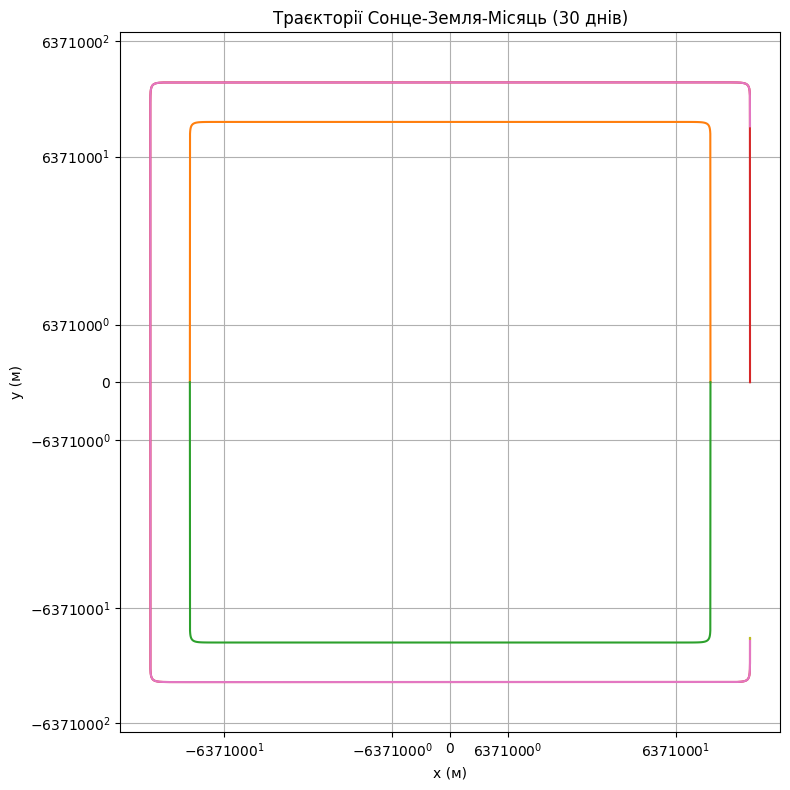

In [1]:

from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots() 

# Гравітаційна стала
G = 6.67430e-11  # м^3 / кг / с^j

# Початкові дані тіл
bodies = {
    "sun": {
        "mass": 1.9885e30,
        "position": np.array([0.0, 0.0, 0.0]),
        "velocity": np.array([0, 0, 0.0]),
        "radius": 696340e3,
    },
    "earth": {
        "mass": 5.9722e24,
        "position": np.array([1.496e11, 0.0, 0.0]),
        "velocity": np.array([0.0, 29783.0, 0.0]),
        "radius": 6371e3,
    },
    "moon": {
        "mass": 7.3477e22,
        "position": np.array([1.496e11, 3.844e8, 0.0]),
        "velocity": np.array([-1022.0, 29783.0, 0.0]),
        "radius": 1737.1e3,
    },
}

names = list(bodies.keys())
n = len(names)

# Формуємо вектор початкових умов: [x, y, z, vx, vy, vz] для кожного тіла
y0 = np.zeros(6 * n)
for i, name in enumerate(names):
    y0[6 * i : 6 * i + 3] = bodies[name]["position"]
    y0[6 * i + 3 : 6 * i + 6] = bodies[name]["velocity"]

def derivatives(t, y):
    dydt = np.zeros_like(y)
    for i in [1, 2]:
        pos_i = y[6 * i : 6 * i + 3]
        vel_i = y[6 * i + 3 : 6 * i + 6]
        acc = np.zeros(3)
        for j in range(n):
            if i == j:
                continue
            pos_j = y[6 * j : 6 * j + 3]
            r_ij = pos_j - pos_i
            dist = np.linalg.norm(r_ij) + 1e-10
            acc += G * bodies[names[j]]["mass"] * r_ij / dist**3
        dydt[6 * i : 6 * i + 3] = vel_i
        dydt[6 * i + 3 : 6 * i + 6] = acc
    return dydt

# Інтегрування системи на 30 днів
t_span = (0, 60 * 60 * 24 * 365)  # від 0 до 30 днів
t_eval = np.linspace(t_span[0], t_span[1], 2000)

sol = solve_ivp(derivatives, t_span, y0, t_eval=t_eval, rtol=1e-9)

# Розбираємо траєкторії кожного тіла
trajectories = {name: sol.y[6 * i : 6 * i + 3] for i, name in enumerate(names)}

# Побудова графіку руху в 2D (x, y)
fig.set_size_inches(8, 8)
for name in names:
    x = trajectories[name][0]
    y = trajectories[name][1]

    ax.plot(x, y, label=name)
    r = bodies[name]["radius"]
    x_body = np.linspace(-r, r, 100)
    y_body = np.sqrt(r**2 - x_body**2)
    ax.plot(x[-1] + x_body, y[-1] + y_body)
    ax.plot(x[-1] + x_body, y[-1] - y_body)

base = bodies['earth']['radius']
plt.xscale("symlog", base=base)
plt.yscale("symlog", base=base)
#ax.legend()
plt.xlabel("x (м)")
plt.ylabel("y (м)")
plt.title("Траєкторії Сонце-Земля-Місяць (30 днів)")
plt.axis("equal")
plt.grid(True)
plt.tight_layout()
plt.show()